In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [ ]:
print("Dataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


In [ ]:
print("\nTarget Variable Distribution:")
print(df['y'].value_counts())

sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution')
plt.show()


In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns[:-1]  # exclude target

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
print("\nPreprocessed Dataset Info:")
print(df_encoded.info())

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')


In [3]:
df_encoded = df.copy()
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = LabelEncoder().fit_transform(df_encoded[column])


In [4]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'k-NN': KNeighborsClassifier()
}

metrics_result = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    support = y_test.shape[0]

    metrics_result.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Support': support
    })

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7303
           1       0.51      0.52      0.52       935

    accuracy                           0.89      8238
   macro avg       0.72      0.73      0.73      8238
weighted avg       0.89      0.89      0.89      8238


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7303
           1       0.66      0.52      0.58       935

    accuracy                           0.92      8238
   macro

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(



k-NN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7303
           1       0.59      0.40      0.47       935

    accuracy                           0.90      8238
   macro avg       0.76      0.68      0.71      8238
weighted avg       0.89      0.90      0.89      8238




Model Evaluation Summary:
                 Model  Accuracy  Precision    Recall  F1-Score  Support
2        Random Forest  0.915392   0.660811  0.522995  0.583881     8238
0  Logistic Regression  0.910537   0.668367  0.420321  0.516087     8238
3                  SVM  0.909565   0.669643  0.401070  0.501672     8238
4                 k-NN  0.899733   0.585827  0.397861  0.473885     8238
1        Decision Tree  0.888808   0.509948  0.520856  0.515344     8238


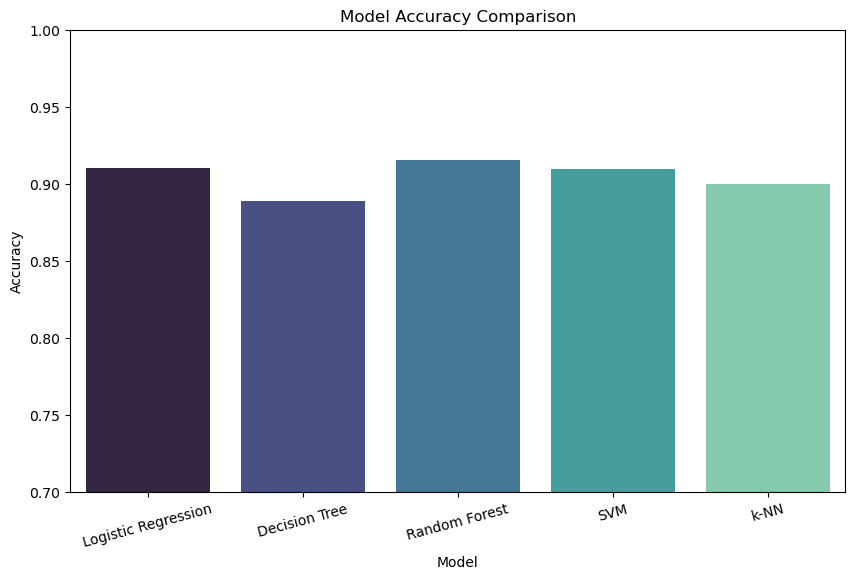

In [6]:
metrics_df = pd.DataFrame(metrics_result)
print("\nModel Evaluation Summary:")
print(metrics_df.sort_values(by='Accuracy', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='mako')
plt.title("Model Accuracy Comparison")
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


In [7]:
best_model = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
worst_model = metrics_df.loc[metrics_df['Accuracy'].idxmin()]

print(f"\n✅ Best Model: {best_model['Model']} with Accuracy = {best_model['Accuracy']:.4f}")
print(f"❌ Worst Model: {worst_model['Model']} with Accuracy = {worst_model['Accuracy']:.4f}")



✅ Best Model: Random Forest with Accuracy = 0.9154
❌ Worst Model: Decision Tree with Accuracy = 0.8888
